<img style="float: right;" src="https://www.h-ka.de/typo3conf/ext/in2template/Resources/Public/Images/Icons/Favicons/favicon-256x256.png">

# Convolutional Networks

So far we have worked with deep fully-connected networks, using them to explore different optimization strategies and network architectures. Fully-connected networks are a good testbed for experimentation because they are very computationally efficient, but in practice all state-of-the-art results use convolutional networks instead.

First you will implement several layer types that are used in convolutional networks. You will then use these layers to train a convolutional network on the CIFAR-10 dataset.

<!-- An interactive 2D visualization of a CNN can be found [here](https://www.cs.ryerson.ca/~aharley/vis/conv/flat.html). When playing with the example first draw a number (0...9) in the upper left box. Then note the connections between the layers, while hovering over the results, showing the receptive field for each convolution. 
 -->
The original code for this exercise was published as an assignment in the [CS231n](http://cs231n.stanford.edu/index.html) course at Uni Standford. The code was modified to fit the syllabus for the lecture "[Neuronale Netze in Bildverarbeitung](https://www.h-ka.de/fileadmin/Hochschule_Karlsruhe_HKA/Informationsmaterialien/HKA_FK-EIT_Sem7_NeuronaleNetze_01.pdf)" at HKA.

## Student Details:

- FirstName: Nico
- LastName: Weber
- MatriculationNumber: 86071
----------

In [37]:
# As usual, a bit of setup
import numpy as np
import matplotlib.pyplot as plt
from EITB712M.classifiers.cnn import *
from EITB712M.data_utils import get_CIFAR10_data
from EITB712M.gradient_check import eval_numerical_gradient_array, eval_numerical_gradient
from EITB712M.layers import *
from EITB712M.fast_layers import *
from EITB712M.solver import Solver

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

def rel_error(x, y):
  """ returns relative error """
  return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Convolution: Naive forward pass

The core of a convolutional network is the convolution operation.

### Let's first have a look at the sizes:
- The input $X$ consists of $N$ data points, each with $C$ channels, height $H$ and width $W$.
    - Hence the input has a size of $[NxCxHxW]$.
- We convolve each input $X$ with $W$ that stores $F$ different filters, where each filter spans all $C$ channels and has height $H_F$ and width $W_F$. 
    - Hence the filters have a size of $[FxCxH_FxW_F]$.
- The Biases in $B$ have the shape of $[F]$
- The output $O$ of the convolution has the shape of $[NxFxH'xW']$ with the padding $P$ and stride $S$:<br><br>
    - $H' = \frac{H - H_F + 2 P}{S}+1$<br><br>
    - $W' = \frac{W - W_F + 2 P}{S}+1$

During the implementation it is a good idea to assert that $H'$ and $W'$ will result in an integer. 

**Example:**
- x of size $[NxCxHxW]=[2x3x4x4]$<br><br>
- w of size $[FxCxH_FxW_F]=[3x3x4x4]$<br><br>
- $S=2$, $P=1$<br><br>
- $H' = \frac{H - H_F + 2 P}{S}+1=\frac{4 - 4 + 2}{2}+1=2$<br><br>
- $W' = \frac{W - W_F + 2 P}{S}+1=\frac{4 - 4 + 2}{2}+1=2$<br><br>
- Resulting in an output $O$ of $[NxFxH'xW']=[2x3x2x2]$

### OK, let's have a look at the convolution operation:

- First you need to pad the number of zeros, e.g. by using the `np.pad` function, to the input. 
    - So the input $X$ will grow to $X'$ with a size of $[NxCx(H+2P)x(W+2P)]$, the following picture provides an example for a single image with $P=1$:<br>
    <img width="300" src="https://www.ismailmebsout.com/static/f6b783b838779d7b3f909f8ce1eab43b/e00f7/zero_padding.webp"> **Source: ismailmebsout.com**<br><br>     
- The the convolution is performed for each data point $N$, over all channels $C$ and for each filter $F$.
    - The following image provides an overview about the process **for a single channel**:<br>
    <img width="300" src="https://www.ismailmebsout.com/static/08a1560310f23ca8c9073cd04ca56a63/e00f7/vef2d.webp"> **Source: ismailmebsout.com**<br><br>    
- Another nice graphical example for convolution with $S=2$, $P=1$ can be found [here](https://cs231n.github.io/assets/conv-demo/index.html).
    - Notice the movement of the filter with stride $S=2$ is used.<br><br>    
- The convolution over several layers of a tensor can be difficult to understand, especially when using more then one filter.
    - One thing that can help: Each convolution over all the input channels results in a 1 channel matrix.
    
For more details on the forward path of the convolution please refer to the script.

-----------
<span style="color:blue">**In the file `EITB712M/layers.py`, implement the forward pass for the convolution layer in the function `conv_forward_naive`.**</span>

You don't have to worry too much about efficiency at this point; just write the code in whatever way you find most clear.

Remember: In the Conv-Layer the convolution is performed using the weights in the filters. You can also implement it very similar to the affine layer. Instead of the matrix multiplication with the complete picture only patches of the picutre with the matching filter size are multiplied with the filter(s). 

Hint: Make sure you understand what each dimension of the input and output mean. Develop what your strategy for the algorithm e.g. on paper first, then implement it. Don't do both at the same time. 

You can test your implementation by running the following:

In [38]:
x_shape = (2, 3, 4, 4) # (N=2,C=3, H=4, W=4), e.g. N=2 picture with C=3 channels, and  H=4 x  W=4 pixels in size
w_shape = (3, 3, 4, 4) # (F=2,C=3,HH=4,WW=4), e.g. F=3 filters with C=3 channels, and HH=4 x WW=4 pixels in size
x = np.linspace(-0.1, 0.5, num=np.prod(x_shape)).reshape(x_shape)
w = np.linspace(-0.2, 0.3, num=np.prod(w_shape)).reshape(w_shape)
b = np.linspace(-0.1, 0.2, num=3)

conv_param = {'stride': 2, 'pad': 1}

In [39]:
out, _ = conv_forward_naive(x, w, b, conv_param)
correct_out = np.array([[[[-0.08759809, -0.10987781],
                           [-0.18387192, -0.2109216 ]],
                          [[ 0.21027089,  0.21661097],
                           [ 0.22847626,  0.23004637]],
                          [[ 0.50813986,  0.54309974],
                           [ 0.64082444,  0.67101435]]],
                         [[[-0.98053589, -1.03143541],
                           [-1.19128892, -1.24695841]],
                          [[ 0.69108355,  0.66880383],
                           [ 0.59480972,  0.56776003]],
                          [[ 2.36270298,  2.36904306],
                           [ 2.38090835,  2.38247847]]]])

# Compare your output to ours; difference should be around e-8
print('Testing conv_forward_naive')
print('difference: ', rel_error(out, correct_out))

Testing conv_forward_naive
difference:  2.2121476417505994e-08


# Convolution: Naive backward pass

Implementing the forward pass is less then half of the way, as the backward pass is quite tricky.
Nevertheless we provided quite a bit of theory in the forward convolution pass that will help us to implement the backward pass. 

### First let's recosider what we want to achieve: 
- Our convolution layer (at layer $l$) will be embedded between other layers, e.g. pooling-layer before ($l-1$) and a relu-layer after ($l+1$).
- While we took the inputs ($X$,$W$,$B$) in the forward pass to calculate the output ($O$) we will calculate the partial (downstream) derrivatives $\frac {\partial L}{\partial X}$, $\frac {\partial L}{\partial W}$ and $\frac {\partial L}{\partial B}$. All partial derrivatives will have the same size as the variables. 
- For the calculation we'll get the upstream gradient $\frac {\partial L}{\partial O}$ from the next layer ($l+1$), that has the same size as the output $O$ of $[NxFxH'xW']$.
- As we discussed in the lecture we'll multiply the upstream gradient $\frac {\partial L}{\partial O}$ with our local gradients $\frac {\partial O}{\partial X}$, $\frac {\partial O}{\partial F}$ and $\frac {\partial O}{\partial B}$ (chain rule) to get the partial (downstream) derrivatives:
    - $\frac {\partial L}{\partial X}=\frac {\partial L}{\partial O}\frac {\partial O}{\partial X}$<br><br>
    - $\frac {\partial L}{\partial F}=\frac {\partial L}{\partial O}\frac {\partial O}{\partial F}$<br><br>
    - $\frac {\partial L}{\partial B}=\frac {\partial L}{\partial O}\frac {\partial O}{\partial B}$<br><br>

- **Why do we need to calculate $\frac {\partial L}{\partial X}$, $\frac {\partial L}{\partial F}$ and $\frac {\partial L}{\partial B}$?**
    - $\frac {\partial L}{\partial F}$ is used to update the filters: $F_{n+1}=F_n - \frac {\partial L}{\partial F}$. <br><br>
    - $\frac {\partial L}{\partial B}$ is used to update the biases: $B_{n+1}=B_n - \frac {\partial L}{\partial B}$. <br><br>
    - $\frac {\partial L}{\partial X}$ is (or will become) the upstream gradient for the previous layer ($l-1$). 

### Finding the local gradients:

The derrivatives of the gradients are discussed in the script of the lecture.

In [40]:
np.random.seed(712)
x = np.random.randn(4, 3, 5, 5)
w = np.random.randn(2, 3, 3, 3)
b = np.random.randn(2,)
dout = np.random.randn(4, 2, 5, 5)
conv_param = {'stride': 1, 'pad': 1}

dx_num = eval_numerical_gradient_array(lambda x: conv_forward_naive(x, w, b, conv_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_forward_naive(x, w, b, conv_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_forward_naive(x, w, b, conv_param)[0], b, dout)

out, cache = conv_forward_naive(x, w, b, conv_param)
dx, dw, db = conv_backward_naive(dout, cache)

# Your errors should be around e-8 or less.
print('Testing conv_backward_naive function')
print('dx error: ', rel_error(dx, dx_num))
print('dw error: ', rel_error(dw, dw_num))
print('db error: ', rel_error(db, db_num))

Testing conv_backward_naive function
dx error:  1.206171109549877e-09
dw error:  1.1773684836777193e-09
db error:  1.661068224640408e-12


# Max-Pooling: Naive forward
-----------
<span style="color:blue">**Implement the forward pass for the max-pooling operation in the function `max_pool_forward_naive` in the file `EITB712M/layers.py`.**</span> 

Again, don't worry too much about computational efficiency.

Check your implementation by running the following:

In [41]:
x_shape = (2, 3, 4, 4)
x = np.linspace(-0.3, 0.4, num=np.prod(x_shape)).reshape(x_shape)
pool_param = {'pool_width': 2, 'pool_height': 2, 'stride': 2}

out, _ = max_pool_forward_naive(x, pool_param)

correct_out = np.array([[[[-0.26315789, -0.24842105],
                          [-0.20421053, -0.18947368]],
                         [[-0.14526316, -0.13052632],
                          [-0.08631579, -0.07157895]],
                         [[-0.02736842, -0.01263158],
                          [ 0.03157895,  0.04631579]]],
                        [[[ 0.09052632,  0.10526316],
                          [ 0.14947368,  0.16421053]],
                         [[ 0.20842105,  0.22315789],
                          [ 0.26736842,  0.28210526]],
                         [[ 0.32631579,  0.34105263],
                          [ 0.38526316,  0.4       ]]]])

# Compare your output with ours. Difference should be on the order of e-8.
print('Testing max_pool_forward_naive function:')
print('difference: ', rel_error(out, correct_out))

Testing max_pool_forward_naive function:
difference:  4.1666665157267834e-08


# Max-Pooling: Naive backward
-----------
<span style="color:blue">**Implement the backward pass for the max-pooling operation in the function `max_pool_backward_naive` in the file `EITB712M/layers.py`.**</span> 

You don't need to worry about computational efficiency.

Check your implementation with numeric gradient checking by running the following:

In [42]:
np.random.seed(231)
x = np.random.randn(3, 2, 8, 8)
dout = np.random.randn(3, 2, 4, 4)
pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

dx_num = eval_numerical_gradient_array(lambda x: max_pool_forward_naive(x, pool_param)[0], x, dout)

out, cache = max_pool_forward_naive(x, pool_param)
dx = max_pool_backward_naive(dout, cache)

# Your error should be on the order of e-12
print('Testing max_pool_backward_naive function:')
print('dx error: ', rel_error(dx, dx_num))

Testing max_pool_backward_naive function:
dx error:  3.27562514223145e-12


# Fast layers

Making convolution and pooling layers fast can be challenging. To spare you the pain, we've provided fast implementations of the forward and backward passes for convolution and pooling layers in the file `EITB712M/fast_layers.py`.

The fast convolution implementation depends on a Cython extension; to compile it change to the folder EITB712M and execute the the following commands within a shell: 

In [43]:
# <<!RUN IN A SHELL!>>
# conda activate EITB712M
# python setup.py build_ext --inplace

---
<span style="color:blue">**Very Important, Please Read**. You have to **restart** the Kernel after compiling the cython extension. This will restart the kernel which means local variables will be lost. Just re-execute the cells from top to bottom and skip the cell below as you only need to run it once for the compilation step.**</span> 

---

# Convolutional "sandwich" layers
Previously we introduced the concept of "sandwich" layers that combine multiple operations into commonly used patterns. In the file `EITB712M/layer_utils.py` you will find sandwich layers that implement a few commonly used patterns for convolutional networks. Run the cells below to sanity check they're working.

In [44]:
from EITB712M.layer_utils import conv_relu_pool_forward, conv_relu_pool_backward
np.random.seed(231)
x = np.random.randn(2, 3, 16, 16)
w = np.random.randn(3, 3, 3, 3)
b = np.random.randn(3,)
dout = np.random.randn(2, 3, 8, 8)
conv_param = {'stride': 1, 'pad': 1}
pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

out, cache = conv_relu_pool_forward(x, w, b, conv_param, pool_param)
dx, dw, db = conv_relu_pool_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], b, dout)

# Relative errors should be around e-8 or less
print('Testing conv_relu_pool')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing conv_relu_pool
dx error:  9.591132621921372e-09
dw error:  5.802401370096438e-09
db error:  1.0146343411762047e-09


In [45]:
from EITB712M.layer_utils import conv_relu_forward, conv_relu_backward
np.random.seed(231)
x = np.random.randn(2, 3, 8, 8)
w = np.random.randn(3, 3, 3, 3)
b = np.random.randn(3,)
dout = np.random.randn(2, 3, 8, 8)
conv_param = {'stride': 1, 'pad': 1}

out, cache = conv_relu_forward(x, w, b, conv_param)
dx, dw, db = conv_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: conv_relu_forward(x, w, b, conv_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_relu_forward(x, w, b, conv_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_relu_forward(x, w, b, conv_param)[0], b, dout)

# Relative errors should be around e-8 or less
print('Testing conv_relu:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing conv_relu:
dx error:  1.5218619980349303e-09
dw error:  2.702022646099404e-10
db error:  1.451272393591721e-10


# Three-layer ConvNet
Now that you have implemented all the necessary layers, we can put them together into a simple convolutional network.

<span style="color:blue">**Open the file `EITB712M/classifiers/cnn.py` and look the implementation of the `ThreeLayerConvNet` class. You should try to understand the structure of the three-layer ConvNet and the re-use of the above implemented functions.**</span>

## Sanity check loss
After you build a new network, one of the first things you should do is sanity check the loss. When we use the softmax loss, we expect the loss for random weights (and no regularization) to be about `log(C)` for `C` classes. When we add regularization the loss should go up slightly.

In [46]:
model = ThreeLayerConvNet()

N = 50
X = np.random.randn(N, 3, 32, 32)
y = np.random.randint(10, size=N) # that means we have 10 classes

loss, grads = model.loss(X, y)
print('Initial loss (no regularization): ', loss)

model.reg = 0.5
loss, grads = model.loss(X, y)
print('Initial loss (with regularization): ', loss)

Initial loss (no regularization):  2.302586071243987
Initial loss (with regularization):  2.5082556207706337


## Gradient check
After the loss looks reasonable, you can use numeric gradient checking to make sure that your backward pass is correct. When you use numeric gradient checking you should use a small amount of artifical data and a small number of neurons at each layer. Note: correct implementations may still have relative errors up to the order of e-2.

In [47]:
num_inputs = 2
input_dim = (3, 16, 16)
reg = 0.0
num_classes = 10
np.random.seed(231)
X = np.random.randn(num_inputs, *input_dim)
y = np.random.randint(num_classes, size=num_inputs)

model = ThreeLayerConvNet(num_filters=3, filter_size=3,
                          input_dim=input_dim, hidden_dim=7,
                          dtype=np.float64)
loss, grads = model.loss(X, y)
# Errors should be small, but correct implementations may have
# relative errors up to the order of e-2
for param_name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    param_grad_num = eval_numerical_gradient(f, model.params[param_name], verbose=False, h=1e-6)
    e = rel_error(param_grad_num, grads[param_name])
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W1 max relative error: 1.380104e-04
W2 max relative error: 1.822723e-02
W3 max relative error: 3.064049e-04
b1 max relative error: 3.477652e-05
b2 max relative error: 2.516375e-03
b3 max relative error: 7.945660e-10


## Overfit small data
A nice trick, to check if everything is working fine, is to train your model with just a few training samples. You should be able to overfit small datasets, which will result in very high training accuracy and comparatively low validation accuracy.

In [48]:
cifar10_dir = '../datasets/cifar-10-batches-py'

import os.path

# Get the CIFAR10 data if not present
if os.path.isdir(cifar10_dir):
    print ("CIFAR10 folder exist, skipping download. If you encouter errors, load and unpack the data manually.")
else:
    !mkdir ../datasets/
    !cd ../datasets/ && wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz -O cifar-10-python.tar.gz && tar -xzvf cifar-10-python.tar.gz && rm cifar-10-python.tar.gz 

Syntaxfehler.
Das System kann den angegebenen Pfad nicht finden.


In [49]:
# Load the (preprocessed) CIFAR10 data.

data = get_CIFAR10_data()
for k, v in data.items():
  print('%s: ' % k, v.shape)

X_train:  (49000, 3, 32, 32)
y_train:  (49000,)
X_val:  (1000, 3, 32, 32)
y_val:  (1000,)
X_test:  (1000, 3, 32, 32)
y_test:  (1000,)


In [50]:
np.random.seed(231)

num_train = 100
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

model = ThreeLayerConvNet(weight_scale=1e-2)

solver = Solver(model, small_data,
                num_epochs=15, batch_size=50,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True, print_every=1)
solver.train()

(Iteration 1 / 30) loss: 2.414060
(Epoch 0 / 15) train acc: 0.200000; val_acc: 0.137000
(Iteration 2 / 30) loss: 3.102925
(Epoch 1 / 15) train acc: 0.140000; val_acc: 0.087000
(Iteration 3 / 30) loss: 2.270330
(Iteration 4 / 30) loss: 2.096705
(Epoch 2 / 15) train acc: 0.240000; val_acc: 0.094000
(Iteration 5 / 30) loss: 1.838880
(Iteration 6 / 30) loss: 1.934188
(Epoch 3 / 15) train acc: 0.510000; val_acc: 0.173000
(Iteration 7 / 30) loss: 1.827912
(Iteration 8 / 30) loss: 1.639574
(Epoch 4 / 15) train acc: 0.520000; val_acc: 0.188000
(Iteration 9 / 30) loss: 1.330082
(Iteration 10 / 30) loss: 1.756115
(Epoch 5 / 15) train acc: 0.630000; val_acc: 0.167000
(Iteration 11 / 30) loss: 1.024162
(Iteration 12 / 30) loss: 1.041826
(Epoch 6 / 15) train acc: 0.750000; val_acc: 0.229000
(Iteration 13 / 30) loss: 1.142777
(Iteration 14 / 30) loss: 0.835706
(Epoch 7 / 15) train acc: 0.790000; val_acc: 0.247000
(Iteration 15 / 30) loss: 0.587786
(Iteration 16 / 30) loss: 0.645509
(Epoch 8 / 15) tr

In [51]:
# Print final training accuracy
print(
    "Small data training accuracy:",
    solver.check_accuracy(small_data['X_train'], small_data['y_train'])
)

Small data training accuracy: 0.82


In [52]:
# Print final validation accuracy
print(
    "Small data validation accuracy:",
    solver.check_accuracy(small_data['X_val'], small_data['y_val'])
)

Small data validation accuracy: 0.252


Plotting the loss, training accuracy, and validation accuracy should show clear overfitting:

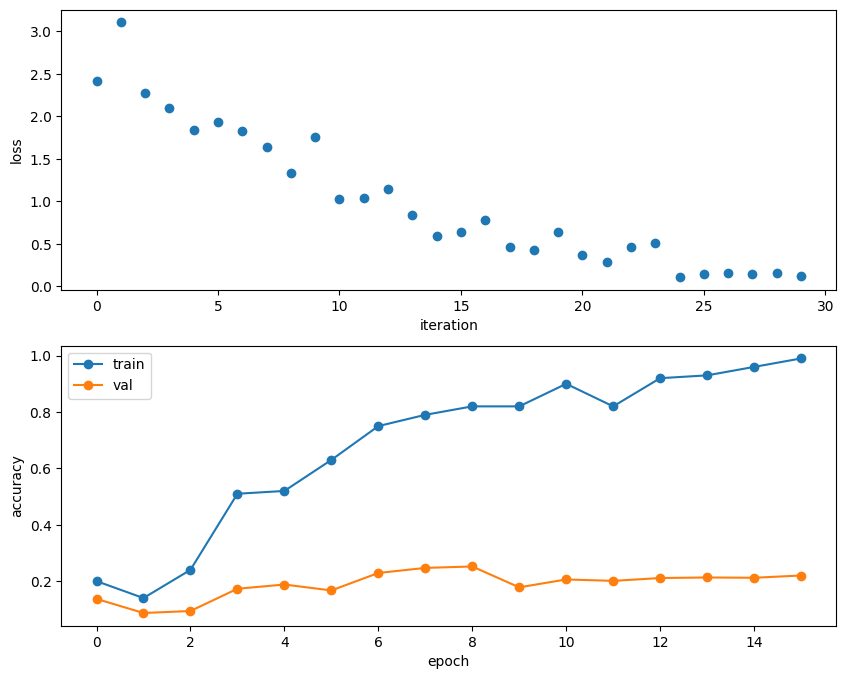

In [53]:
plt.subplot(2, 1, 1)
plt.plot(solver.loss_history, 'o')
plt.xlabel('iteration')
plt.ylabel('loss')

plt.subplot(2, 1, 2)
plt.plot(solver.train_acc_history, '-o')
plt.plot(solver.val_acc_history, '-o')
plt.legend(['train', 'val'], loc='upper left')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

## Train the net
By training the three-layer convolutional network for one epoch.

Remember: Number epoch equal to the number of times the algorithm sees the entire data set. So, each time the algorithm has seen all samples in the dataset, one epoch has completed.

You should achieve greater than 40% accuracy on the training set:

In [ ]:
model = ThreeLayerConvNet(num_filters=512, weight_scale=0.01, hidden_dim=1024, reg=1)

solver = Solver(model, data,
                num_epochs=1, batch_size=16,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True, print_every=5)
solver.train()

(Iteration 1 / 3062) loss: 6722.039454
(Epoch 0 / 1) train acc: 0.112000; val_acc: 0.106000
(Iteration 6 / 3062) loss: 4013.505423
(Iteration 11 / 3062) loss: 2112.256194
(Iteration 16 / 3062) loss: 1104.581735
(Iteration 21 / 3062) loss: 606.961279
(Iteration 26 / 3062) loss: 370.242339
(Iteration 31 / 3062) loss: 280.615440
(Iteration 36 / 3062) loss: 201.185359
(Iteration 41 / 3062) loss: 125.900799
(Iteration 46 / 3062) loss: 116.302563
(Iteration 51 / 3062) loss: 90.392525
(Iteration 56 / 3062) loss: 72.121741
(Iteration 61 / 3062) loss: 58.847295
(Iteration 66 / 3062) loss: 55.791736
(Iteration 71 / 3062) loss: 44.616489
(Iteration 76 / 3062) loss: 45.317108
(Iteration 81 / 3062) loss: 48.964645
(Iteration 86 / 3062) loss: 51.590456
(Iteration 91 / 3062) loss: 53.883477
(Iteration 96 / 3062) loss: 38.520155
(Iteration 101 / 3062) loss: 32.083397
(Iteration 106 / 3062) loss: 25.473413
(Iteration 111 / 3062) loss: 19.771497
(Iteration 116 / 3062) loss: 21.168431
(Iteration 121 / 30

In [ ]:
# Print final training accuracy
print(
    "Full data training accuracy:",
    solver.check_accuracy(small_data['X_train'], small_data['y_train'])
)

In [ ]:
# Print final validation accuracy
print(
    "Full data validation accuracy:",
    solver.check_accuracy(data['X_val'], data['y_val'])
)

# Best value so far: 68.3% (@77% training accuracy) by TS 19.12.2021

## Visualize Filters
You can visualize the first-layer convolutional filters from the trained network by running the following:

In [ ]:
from EITB712M.vis_utils import visualize_grid

grid = visualize_grid(model.params['W1'].transpose(0, 2, 3, 1))
plt.imshow(grid.astype('uint8'))
plt.axis('off')
plt.gcf().set_size_inches(5, 5)
plt.show()